# PointTransformerV2 — Point Cloud Segmentation

Beginner-friendly notebook. Runs top to bottom.

⚠️ Requires `torch-scatter` + `torch-cluster` — install matching wheels from https://data.pyg.org/whl/

In [1]:
# ── Install (run once if needed) ─────────────────────────────────────────────
# pip install torch laspy open3d numpy scikit-learn joblib tqdm mlflow matplotlib
# For PTv1/PTv2/GNN also:
# pip install torch-scatter torch-cluster -f https://data.pyg.org/whl/torch-<VER>+<CUDA>.html

import os, glob, glob, copy, random, logging
import numpy as np
import torch
import torch.nn as nn
import open3d as o3d
import laspy
import joblib
import mlflow
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger(__name__)

# Use GPU if available, otherwise CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Running on: {DEVICE}")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-07-12 11:16:21,875 | INFO | Running on: cuda


In [2]:
# ── Configuration — change values here, nowhere else ────────────────────────
CONFIG = {
    "train_dir"      : "../data/train",      # labelled .las files
    "test_dir"       : "../data/test",       # unlabelled .las files for inference
    "checkpoint_dir" : "../checkpoints",     # where the best model is saved
    "num_classes"    : 2,                 # 0 = environment, 1 = wood powder
    "target_class"   : 1,                 # class we want to highlight (green)
    "val_ratio"      : 0.15,
    "test_ratio"     : 0.15,
    "seed"           : 42,
    # ── training ──
    "epochs"         : 100,
    "patience"       : 100,               # early stop if val mIoU doesn't improve
    "batch_size"     : 2,
    "num_points"     : 16384,             # points per training chunk
    "chunks_per_cloud": 100,
    "lr"             : 1e-6,
    "grad_accum"     : 8,    # gradient accumulation steps (effective batch = batch_size × grad_accum)
    "in_channels"    : 7,                # xyz + height + normals
    # ── visualization ──
    "max_vis_files"  : 0,                # how many test files to show in 3D
    # ── MLflow ──
    "mlflow_uri"     : "http://localhost:5000",
    "mlflow_experiment": "PTV2_Segmentation",
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
NUM_CLASSES = CONFIG["num_classes"]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])


In [3]:
# ── Point cloud loader ───────────────────────────────────────────────────────
def load_pointcloud(path):
    """Read a .las/.laz file. Returns (points[N,3], labels[N] or None)."""
    las = laspy.read(path)
    pts = np.column_stack([np.asarray(las.x),
                           np.asarray(las.y),
                           np.asarray(las.z)]).astype(np.float64)
    labels = None
    for key in ("classification", "label", "labels", "class"):
        if key in las.point_format.dimension_names:
            labels = np.asarray(getattr(las, key), dtype=np.int64)
            break
    return pts, labels

def list_files(folder):
    """Return sorted list of .las/.laz files in a folder."""
    files = []
    for ext in (".las", ".laz"):
        files += glob.glob(os.path.join(folder, "*" + ext))
    return sorted(files)

# ── Split labelled files into train / val / test ─────────────────────────────
all_files = list_files(CONFIG["train_dir"])
assert all_files, f"No .las files found in {CONFIG['train_dir']}"

rng   = np.random.RandomState(CONFIG["seed"])
order = rng.permutation(len(all_files))
n_val  = max(1, int(len(all_files) * CONFIG["val_ratio"]))
n_test = max(1, int(len(all_files) * CONFIG["test_ratio"]))

VAL_FILES   = [all_files[i] for i in order[:n_val]]
TEST_FILES  = [all_files[i] for i in order[n_val : n_val + n_test]]
TRAIN_FILES = [all_files[i] for i in order[n_val + n_test :]]
INFER_FILES = list_files(CONFIG["test_dir"])   # no labels, final inference only

log.info(f"train={len(TRAIN_FILES)}  val={len(VAL_FILES)}  "
         f"test={len(TEST_FILES)}  inference={len(INFER_FILES)}")


2026-07-12 11:16:21,898 | INFO | train=33  val=6  test=6  inference=18


In [4]:
# ── 7-channel feature computation ───────────────────────────────────────────
# Each point gets: normalized xyz (3) + height above floor (1) + surface normal (3)
def make_features(points):
    """Turn raw XYZ into 7-channel features. Returns float32 array (N,7)."""
    center = points.mean(axis=0, keepdims=True)
    scale  = max(np.linalg.norm(points - center, axis=1).max(), 1e-9)
    norm_xyz = ((points - center) / scale).astype(np.float32)

    z = points[:, 2]
    height = ((z - z.min()) / max(z.max() - z.min(), 1e-6)).astype(np.float32)

    # surface normals via Open3D
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(16))
    pcd.orient_normals_to_align_with_direction([0., 0., 1.])
    normals = np.asarray(pcd.normals, dtype=np.float32)

    return np.column_stack([norm_xyz, height[:, None], normals])

# ── Feature cache (compute once per file, reuse every epoch) ─────────────────
FEATURE_CACHE = {}

def get_features(path):
    """Return (features[N,7], labels[N]) for a file, cached after first call."""
    if path not in FEATURE_CACHE:
        pts, lbl = load_pointcloud(path)
        feat = make_features(pts)
        lbl  = np.zeros(len(pts), dtype=np.int64) if lbl is None else lbl
        lbl  = np.clip(lbl, 0, NUM_CLASSES - 1).astype(np.int64)
        FEATURE_CACHE[path] = (pts, feat, lbl)
    return FEATURE_CACHE[path]

log.info("Pre-computing features for train + val files (one-time cost)...")
for f in tqdm(TRAIN_FILES + VAL_FILES, desc="features"):
    get_features(f)
log.info("Done.")


2026-07-12 11:16:21,909 | INFO | Pre-computing features for train + val files (one-time cost)...


features:   0%|          | 0/39 [00:00<?, ?it/s]

2026-07-12 11:16:29,356 | INFO | Done.


In [5]:
# ── Metrics ──────────────────────────────────────────────────────────────────
def compute_miou(true_labels, pred_labels, num_classes):
    """Compute mean Intersection-over-Union across all classes."""
    ious = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            ious.append(tp / (tp + fp + fn))
    return float(np.mean(ious)) if ious else 0.0


def compute_dice(true_labels, pred_labels, num_classes):
    """Compute mean Dice Score across all classes."""
    dices = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            # Dice Formula: 2*TP / (2*TP + FP + FN)
            dices.append((2 * tp) / (2 * tp + fp + fn))
    return float(np.mean(dices)) if dices else 0.0

In [6]:
# ── MLflow setup ─────────────────────────────────────────────────────────────
try:
    mlflow.set_tracking_uri(CONFIG["mlflow_uri"])
    mlflow.set_experiment(CONFIG["mlflow_experiment"])
    MLFLOW_OK = True
    log.info(f"MLflow tracking: {CONFIG['mlflow_uri']}")
except Exception as e:
    MLFLOW_OK = False
    log.warning(f"MLflow not available ({e}) — training continues without logging")


2026-07-12 11:16:29,391 | WARNING | Retrying (Retry(total=6, connect=6, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused")': /api/2.0/mlflow/experiments/get-by-name?experiment_name=PTV2_Segmentation
2026-07-12 11:16:34,032 | WARNING | Retrying (Retry(total=5, connect=5, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused")': /api/2.0/mlflow/experiments/get-by-name?experiment_name=PTV2_Segmentation
2026-07-12 11:16:42,057 | WARNING | Retrying (Retry(total=4, connect=4, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused")': /api/2.0/mlflow/experiments/get-by-name?exper

## Model Architecture

In [7]:
MODEL_NAME = "PointTransformerV2"

from torch_cluster import knn as tc_knn
from torch_scatter import scatter_softmax, scatter_add, scatter_max, scatter_mean

class GVA(nn.Module):
    "Grouped Vector Attention — PTv2 core attention layer."
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        assert ch % g == 0
        self.k, self.g, self.gc = k, g, ch // g
        self.q  = nn.Linear(ch, ch); self.kk = nn.Linear(ch, ch); self.v = nn.Linear(ch, ch)
        self.pm = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.pb = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.w  = nn.Sequential(nn.Linear(ch,ch), nn.ReLU(), nn.Linear(ch,g))
    def forward(self, x, pos, batch):
        e    = tc_knn(pos, pos, self.k, batch, batch)
        c, nb = e[0], e[1]
        dp   = pos[c] - pos[nb]
        pb   = self.pb(dp)
        rel  = (self.q(x)[c] - self.kk(x)[nb]) * self.pm(dp) + pb
        wt   = scatter_softmax(self.w(rel), c, dim=0)
        vg   = (self.v(x)[nb] + pb).view(-1, self.g, self.gc)
        out  = scatter_add(vg * wt.unsqueeze(-1), c, dim=0, dim_size=x.size(0))
        return out.view(-1, self.g * self.gc)

class Block(nn.Module):
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(ch), nn.LayerNorm(ch)
        self.attn = GVA(ch, g, k)
        self.mlp  = nn.Sequential(nn.Linear(ch,ch*2), nn.ReLU(), nn.Linear(ch*2,ch))
    def forward(self, x, pos, batch):
        x = x + self.attn(self.n1(x), pos, batch)
        return x + self.mlp(self.n2(x))

class GridPool(nn.Module):
    def __init__(self, i, o, grid):
        super().__init__()
        self.grid = grid
        self.proj = nn.Sequential(nn.Linear(i,o), nn.ReLU())
    def forward(self, x, pos, batch):
        vox = torch.floor(pos/self.grid).long()
        key = torch.cat([batch.unsqueeze(1), vox], 1)
        _, cl = torch.unique(key, dim=0, return_inverse=True)
        xp, _ = scatter_max(self.proj(x), cl, dim=0)
        return xp, scatter_mean(pos,cl,dim=0), scatter_max(batch,cl,dim=0)[0], cl

class PTv2Seg(nn.Module):
    def __init__(self, nc=NUM_CLASSES, k=16, dims=(48,96,192), g=6):
        super().__init__()
        d = dims
        self.embed = nn.Sequential(nn.Linear(7,d[0]),nn.ReLU(),nn.Linear(d[0],d[0]))
        self.e1=Block(d[0],g,k); self.p1=GridPool(d[0],d[1],0.08)
        self.e2=Block(d[1],g,k); self.p2=GridPool(d[1],d[2],0.16)
        self.e3=Block(d[2],g,k)
        self.u2=nn.Sequential(nn.Linear(d[2]+d[1],d[1]),nn.ReLU()); self.d2=Block(d[1],g,k)
        self.u1=nn.Sequential(nn.Linear(d[1]+d[0],d[0]),nn.ReLU()); self.d1=Block(d[0],g,k)
        self.head=nn.Sequential(nn.LayerNorm(d[0]),nn.Linear(d[0],128),nn.ReLU(),
                                nn.Dropout(0.4),nn.Linear(128,nc))
    def forward(self, x):
        B,C,N = x.shape
        flat  = x.permute(0,2,1).reshape(-1,C).contiguous()
        p0    = flat[:,:3].contiguous()
        b0    = torch.arange(B,device=x.device).repeat_interleave(N)
        h0=self.e1(self.embed(flat),p0,b0)
        h1,p1,b1,c1=self.p1(h0,p0,b0); h1=self.e2(h1,p1,b1)
        h2,p2,b2,c2=self.p2(h1,p1,b1); h2=self.e3(h2,p2,b2)
        u1=self.d2(self.u2(torch.cat([h1,h2[c2]],1)),p1,b1)
        u0=self.d1(self.u1(torch.cat([h0,u1[c1]],1)),p0,b0)
        return self.head(u0).view(B,N,-1).permute(0,2,1)

model = PTv2Seg()
log.info(f"PTv2 parameters: {sum(p.numel() for p in model.parameters()):,}")


2026-07-12 11:20:35,372 | INFO | PTv2 parameters: 679,424


## Dataset & DataLoader

In [8]:
# ── Dataset: one random chunk per call ───────────────────────────────────────
from torch.utils.data import Dataset, DataLoader

class PointCloudDataset(Dataset):
    """Returns one fixed-size sphere-crop chunk per item.
    This class only handles data — no training logic here."""
    def __init__(self, files, augment=True):
        self.files   = list(files)
        self.augment = augment
        self.N       = CONFIG["num_points"]
        self.chunks  = CONFIG["chunks_per_cloud"]

    def __len__(self):
        return len(self.files) * self.chunks

    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)

        # pick N nearest points around a random seed point
        if n <= self.N:
            chosen = np.random.choice(n, self.N, replace=True)
        else:
            seed = np.random.randint(n)
            dist = ((feat[:, :3] - feat[seed, :3]) ** 2).sum(1)
            chosen = np.argpartition(dist, self.N - 1)[:self.N]

        x = feat[chosen].copy()    # (N, 7)
        y = lbl[chosen].copy()     # (N,)

        # data augmentation: random rotation around vertical axis
        if self.augment:
            angle = np.random.uniform(0, 2 * np.pi)
            c, s  = np.cos(angle), np.sin(angle)
            R     = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], np.float32)
            x[:, :3]  = x[:, :3]  @ R.T   # rotate xyz
            x[:, 4:7] = x[:, 4:7] @ R.T   # rotate normals

        # shape: (channels, points) for Conv1d / attention layers
        return torch.from_numpy(x.T), torch.from_numpy(y)


## Training

In [9]:
# ── Training loop with periodic checkpointing ────────────────────────────────
# Every SAVE_EVERY epochs:  saves model + optimizer state → resume after power cut
# Always keeps:             the BEST val-mIoU model as a separate file
# On resume:                loads the LATEST periodic checkpoint and continues
# Disk policy:              only keeps the last 2 periodic checkpoints (saves space)

SAVE_EVERY = 10    # save a checkpoint every this many epochs

def train_model(model, model_name):
    """Train the model with periodic saving. Resumes automatically if a
    checkpoint exists. Returns the model loaded with the best weights."""

    ckpt_dir  = CONFIG["checkpoint_dir"]
    best_path = os.path.join(ckpt_dir, f"{model_name}_best.pth")

    # ── helper: find the latest periodic checkpoint ───────────────────────────
    def latest_periodic():
        """Return (epoch, path) of the most recent periodic checkpoint, or (0, None)."""
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))   # sorted alphabetically = epoch order
        if not files:
            return 0, None
        # extract epoch number from filename, pick the highest
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        return epoch_of(files[-1]), files[-1]

    # ── helper: delete old periodic checkpoints, keep only the last 2 ─────────
    def prune_old_checkpoints(keep=2):
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        for old in files[:-keep]:
            try:    os.remove(old); log.info(f"Removed old checkpoint: {old}")
            except: pass

    # ── data loaders ──────────────────────────────────────────────────────────
    train_loader = DataLoader(
        PointCloudDataset(TRAIN_FILES, augment=True),
        batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(
        PointCloudDataset(VAL_FILES, augment=False),
        batch_size=CONFIG["batch_size"], shuffle=False)

    # move model to GPU FIRST so optimizer tracks GPU parameters from the start
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                                  weight_decay=1e-4)
    loss_fn   = nn.CrossEntropyLoss()

    # ── try to resume from the latest periodic checkpoint ────────────────────
    start_epoch = 1
    best_miou   = -1.0
    no_improve  = 0
    history     = []

    resume_epoch, resume_path = latest_periodic()
    if resume_path:
        log.info(f"Resuming from {resume_path} (epoch {resume_epoch})")
        ckpt = torch.load(resume_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        # move optimizer state tensors to the same device as the model
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(DEVICE)
        start_epoch = ckpt["epoch"] + 1
        best_miou   = ckpt.get("best_miou",   -1.0)
        no_improve  = ckpt.get("no_improve",   0)
        history     = ckpt.get("history",      [])
        log.info(f"Resumed: start_epoch={start_epoch}  best_miou={best_miou:.4f}")
    else:
        log.info(f"No checkpoint found — training from scratch.")

    # ── if already fully trained, just load best and return ──────────────────
    if start_epoch > CONFIG["epochs"]:
        log.info("Training already complete. Loading best model.")
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        return model

    run_name = f"{model_name}_seg"
    with (mlflow.start_run(run_name=run_name) if MLFLOW_OK
          else open(os.devnull, "w")) as _:

        if MLFLOW_OK:
            mlflow.log_params({
                "model"       : model_name,
                "epochs"      : CONFIG["epochs"],
                "batch_size"  : CONFIG["batch_size"],
                "num_points"  : CONFIG["num_points"],
                "lr"          : CONFIG["lr"],
                "start_epoch" : start_epoch,
            })

        accumulation_steps = CONFIG.get("grad_accum", 4)  # gradient accumulation steps

        for epoch in range(start_epoch, CONFIG["epochs"] + 1):

            # ── train one epoch ───────────────────────────────────────────────
            model.train()
            optimizer.zero_grad()
            
            train_loss_sum = 0.0
            train_correct = 0
            train_total = 0

            for i, (x, y) in enumerate(train_loader):
                x, y = x.to(DEVICE), y.to(DEVICE)
                
                # Forward
                out = model(x)
                loss = loss_fn(out, y)
                
                # Tracking metrics (before scaling loss)
                train_loss_sum += loss.item() * x.size(0)
                preds = out.argmax(dim=1)
                train_correct += (preds == y).sum().item()
                train_total += y.numel()

                # Gradient accumulation
                loss = loss / accumulation_steps
                loss.backward()

                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()

            epoch_train_loss = train_loss_sum / len(train_loader.dataset)
            epoch_train_acc = train_correct / train_total

            # ── validate ─────────────────────────────────────────────────────
            model.eval()
            val_loss_sum = 0.0
            val_correct = 0
            val_total = 0
            all_true, all_pred = [], []
            
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    
                    out = model(x)
                    loss = loss_fn(out, y)
                    
                    val_loss_sum += loss.item() * x.size(0)
                    preds = out.argmax(dim=1)
                    val_correct += (preds == y).sum().item()
                    val_total += y.numel()

                    all_pred.extend(preds.cpu().numpy().ravel())
                    all_true.extend(y.cpu().numpy().ravel())

            epoch_val_loss = val_loss_sum / len(val_loader.dataset)
            epoch_val_acc = val_correct / val_total
            
            # Compute mIoU and Dice
            miou = compute_miou(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            dice = compute_dice(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            
            history.append({"epoch": epoch, "val_miou": miou, "val_loss": epoch_val_loss})
            
            # ── Logging to Console ───────────────────────────────────────────
            log.info(
                f"Epoch {epoch:3d}/{CONFIG['epochs']} | "
                f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | "
                f"mIoU: {miou:.4f} | Dice: {dice:.4f}"
            )

            # ── Logging to MLflow ────────────────────────────────────────────
            if MLFLOW_OK:
                mlflow.log_metrics({
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss,
                    "train_acc": epoch_train_acc,
                    "val_acc": epoch_val_acc,
                    "val_miou": miou,
                    "val_dice": dice
                }, step=epoch)

            # ── update best model ─────────────────────────────────────────────
            if miou > best_miou + 1e-4:
                best_miou  = miou
                no_improve = 0
                torch.save({"model_state": model.state_dict(),
                            "best_val_miou": best_miou}, best_path)
                log.info(f"  ✓ New best mIoU {best_miou:.4f} → saved {best_path}")
            else:
                no_improve += 1

            # [নিচের periodic checkpoint এবং early stopping এর কোড আগের মতই থাকবে] ...

            # ── periodic checkpoint (every SAVE_EVERY epochs) ─────────────────
            if epoch % SAVE_EVERY == 0 or epoch == CONFIG["epochs"]:
                periodic_path = os.path.join(ckpt_dir,
                                             f"{model_name}_epoch_{epoch:04d}.pth")
                torch.save({
                    "model_state"     : model.state_dict(),
                    "optimizer_state" : optimizer.state_dict(),
                    "epoch"           : epoch,
                    "best_miou"       : best_miou,
                    "no_improve"      : no_improve,
                    "history"         : history,
                }, periodic_path)
                log.info(f"  💾 Periodic checkpoint saved → {periodic_path}")
                prune_old_checkpoints(keep=2)   # keep only last 2 periodic files

            # ── early stopping ────────────────────────────────────────────────
            if no_improve >= CONFIG["patience"]:
                log.info(f"Early stop at epoch {epoch} "
                         f"(no improvement for {CONFIG['patience']} epochs)")
                break

        if MLFLOW_OK:
            mlflow.log_metric("best_val_miou", best_miou)

    # ── load best weights before returning ────────────────────────────────────
    if os.path.exists(best_path):
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        log.info(f"Loaded best model (mIoU={best_miou:.4f}) from {best_path}")
    model.to("cpu")
    return model


In [10]:
model = train_model(model, MODEL_NAME)

2026-07-12 11:20:36,154 | INFO | Resuming from ../checkpoints/PointTransformerV2_epoch_0320.pth (epoch 320)
2026-07-12 11:20:36,182 | INFO | Resumed: start_epoch=321  best_miou=0.9097
2026-07-12 11:20:36,183 | INFO | Training already complete. Loading best model.


## Visualization helper

In [11]:
# ── Visualization: Open3D ────────────────────────────────────────────────────
# Green = target (wood powder)   |   Red = others (environment)
def visualize_segmentation(points, predictions, title="Segmentation"):
    """Open an Open3D window showing the segmentation result."""
    colors = np.zeros((len(points), 3), dtype=np.float64)
    colors[predictions == CONFIG["target_class"]] = [0.0, 0.8, 0.0]   # green
    colors[predictions != CONFIG["target_class"]] = [0.8, 0.0, 0.0]   # red

    pcd = o3d.geometry.PointCloud()
    # centre the cloud so it appears at the origin
    center = points.mean(axis=0)
    pcd.points = o3d.utility.Vector3dVector(
        (points - center).astype(np.float64))
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # XYZ axes
    span = float((points.max(0) - points.min(0)).max()) * 0.5
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=span)

    n_target = int((predictions == CONFIG["target_class"]).sum())
    n_other  = len(predictions) - n_target
    full_title = (f"{title}  |  green(target)={n_target:,}  "
                  f"red(others)={n_other:,}")
    # o3d.visualization.draw_geometries([pcd, axes],
    #                                    window_name=full_title,
    #                                    width=1280, height=800)


## Inference helper

In [12]:
# ── Full-cloud inference ──────────────────────────────────────────────────────
@torch.no_grad()
def predict_full_cloud(model, path):
    """Label every point in a file using the trained model.
    The cloud is split into fixed-size chunks, each chunk goes through the model,
    results are stitched back together."""
    model.eval()
    pts, feat, lbl = get_features(path)
    n    = len(feat)
    N    = CONFIG["num_points"]

    # random order so every point is covered
    perm = np.random.RandomState(0).permutation(n)
    pad  = (N - n % N) % N
    if pad:
        perm = np.concatenate([perm, perm[:pad]])
    chunks = perm.reshape(-1, N)

    preds = np.zeros(n, dtype=np.int64)
    model.to(DEVICE)
    for start in range(0, len(chunks), CONFIG["batch_size"]):
        cid = chunks[start : start + CONFIG["batch_size"]]
        x   = torch.from_numpy(feat[cid].transpose(0, 2, 1)).to(DEVICE)
        out = model(x).argmax(dim=1).cpu().numpy()
        preds[cid.ravel()] = out.ravel()
    model.to("cpu")
    return pts, preds, lbl


## Volume Estimation (TIN)

Segmentation-এর পরে target points থেকে volume বের করা হয়।

**Pipeline (সব `vol_TIN()`-এর ভেতরে):**
1. **SOR** — noisy বিচ্ছিন্ন point বাদ (statistical distance filter)
2. **DBSCAN largest cluster** — stray mislabeled points বাদ
3. **TIN integration** — 2D Delaunay → Σ Area₂D(triangle) × mean height
   - Floor baseline = scanned z-এর `floor_pct` percentile (outer-shell scan-এ আলাদা floor point থাকে না)
   - কোনো alpha clipping নেই — DBSCAN-ই stray point সামলায়; clipping করলে কিনারার বৈধ triangle কেটে গিয়ে volume কমে যেত
4. **Bootstrap CI** — ৮০ বার subsample করে std + 95% confidence interval


In [13]:
# ── Volume Estimation: TIN-based volumetric integration ─────────────────────
from scipy.spatial import Delaunay, cKDTree


def sor_filter(pts, k=16, std_ratio=2.0):
    """Statistical Outlier Removal: mean-kNN-distance > mean + std_ratio*std
    হলে সেই point বাদ। Returns (filtered_pts, kept_mask)."""
    pts = np.asarray(pts, np.float64)
    if len(pts) <= k + 1:
        return pts, np.ones(len(pts), bool)
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=k + 1)          # col-0 = নিজেই (দূরত্ব 0)
    mean_dist = d[:, 1:].mean(axis=1)
    thr  = mean_dist.mean() + std_ratio * mean_dist.std()
    mask = mean_dist <= thr
    return pts[mask], mask


def extract_main_cluster(pts, eps=0.15, min_samples=8):
    """DBSCAN দিয়ে সবচেয়ে বড় connected cluster রাখা — stray points বাদ।
    এর পরে আর alpha clipping লাগে না।"""
    pts = np.asarray(pts, np.float64)
    if len(pts) < min_samples * 2:
        return pts
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        labels = np.asarray(pcd.cluster_dbscan(eps=eps, min_points=min_samples))
        valid = labels[labels >= 0]
        if valid.size == 0:
            return pts
        main_lbl = np.bincount(valid).argmax()
        result = pts[labels == main_lbl]
        return result if len(result) >= min_samples else pts
    except Exception as e:
        log.warning(f"[TIN] cluster extraction failed ({e}) -> using all points")
        return pts


def tin_integrate(pts, floor_pct=0.5):
    """Delaunay TIN integration.
    floor baseline = scanned z-এর floor_pct percentile (pile-এর base প্রান্ত)।
    Volume = Σ Area2D(triangle) × mean_height(triangle)."""
    pts = np.asarray(pts, np.float64)
    if len(pts) < 4:
        return float("nan")

    floor_z = np.percentile(pts[:, 2], floor_pct)
    h  = pts[:, 2] - floor_z
    xy = pts[:, :2]
    try:
        tri = Delaunay(xy)
    except Exception as e:
        log.warning(f"[TIN] Delaunay failed ({e})")
        return float("nan")

    t = tri.simplices
    p0, p1, p2 = xy[t[:, 0]], xy[t[:, 1]], xy[t[:, 2]]
    h0, h1, h2 = h[t[:, 0]], h[t[:, 1]], h[t[:, 2]]

    cross  = ((p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
             - (p1[:, 1] - p0[:, 1]) * (p2[:, 0] - p0[:, 0]))
    area2d = np.abs(cross) / 2.0
    mean_h = (h0 + h1 + h2) / 3.0
    valid  = mean_h > 0
    return float(np.sum(area2d[valid] * mean_h[valid]))


def bootstrap_tin_confidence(pts, n_bootstrap=80, subsample_frac=0.85,
                             floor_pct=0.5, seed=0):
    """Bootstrap: বারবার subsample করে TIN চালিয়ে uncertainty মাপা।
    Returns {'std', 'ci_low', 'ci_high'} বা None।"""
    rng = np.random.RandomState(seed)
    n = len(pts)
    n_sub = max(10, int(n * subsample_frac))
    estimates = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n_sub, replace=False)
        v = tin_integrate(pts[idx], floor_pct=floor_pct)
        if np.isfinite(v) and v > 0:
            estimates.append(v)
    if len(estimates) < 5:
        return None
    arr = np.array(estimates)
    return {"std":     round(float(arr.std()), 5),
            "ci_low":  round(float(np.percentile(arr, 2.5)), 5),
            "ci_high": round(float(np.percentile(arr, 97.5)), 5)}


def vol_TIN(pts, sor_k=16, sor_std=2.0, cluster_eps=0.15,
            floor_pct=0.5, run_bootstrap=True, n_bootstrap=80):
    """সম্পূর্ণ volume pipeline: SOR → largest cluster → TIN [→ bootstrap CI].
    Returns (volume, confidence_dict_or_None). একক = pts-এর এককের ঘন (m³)।"""
    pts = np.asarray(pts, np.float64)
    if len(pts) < 10:
        return float("nan"), None

    pts, _ = sor_filter(pts, k=sor_k, std_ratio=sor_std)          # 1. SOR
    if len(pts) < 10:
        return float("nan"), None

    pts = extract_main_cluster(pts, eps=cluster_eps)               # 2. cluster
    if len(pts) < 10:
        return float("nan"), None

    volume = tin_integrate(pts, floor_pct=floor_pct)               # 3. TIN

    conf = None                                                    # 4. CI
    if run_bootstrap and len(pts) >= 20:
        conf = bootstrap_tin_confidence(pts, n_bootstrap=n_bootstrap,
                                        floor_pct=floor_pct)
    return float(volume), conf


## Testing  (held-out test files with labels)

In [14]:
# ── Testing on held-out test files ───────────────────────────────────────────
log.info("=== TESTING ===")
test_mious = []
for path in TEST_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    miou = compute_miou(lbl, preds, NUM_CLASSES)
    test_mious.append(miou)
    log.info(f"  {name}: mIoU = {miou:.4f}")

log.info(f"Mean test mIoU: {np.mean(test_mious):.4f}")

# ── Visualize + volume for the first few test files ──────────────────────────
for path in TEST_FILES[:CONFIG["max_vis_files"]]:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, _ = predict_full_cloud(model, path)

    # segmentation → vol_TIN → volume
    target_pts   = pts[preds == CONFIG["target_class"]]
    volume, conf = vol_TIN(target_pts)

    n_tot = len(pts)
    n_tgt = len(target_pts)
    print(f"\n{'─'*55}")
    print(f"  File          : {name}")
    print(f"  Total Points  : {n_tot:,}")
    print(f"  Target Points : {n_tgt:,}")
    print(f"  Other Points  : {n_tot - n_tgt:,}")
    print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
    print(f"  Est. Volume   : {volume:.4f} m³")
    if conf:
        print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
              f"  (±{conf['std']:.4f})")
    print(f"{'─'*55}")

    visualize_segmentation(pts, preds,
                           title=f"{MODEL_NAME} | {name} | V={volume:.4f} m³")


2026-07-12 11:20:36,248 | INFO | === TESTING ===
2026-07-12 11:20:39,091 | INFO |   sample_data_0013: mIoU = 0.8358
2026-07-12 11:20:42,490 | INFO |   sample_data_0020: mIoU = 0.8685
2026-07-12 11:20:47,013 | INFO |   sample_data_0017: mIoU = 0.8731
2026-07-12 11:20:50,432 | INFO |   sample_data_0012: mIoU = 0.8742
2026-07-12 11:20:53,727 | INFO |   sample_data_0015: mIoU = 0.8782
2026-07-12 11:20:55,784 | INFO |   sample_data_0031: mIoU = 0.6945
2026-07-12 11:20:55,784 | INFO | Mean test mIoU: 0.8374


## Final Inference  (`data/test`, no labels)

In [15]:
# ── Final inference on data/test (no labels needed) ──────────────────────────
if INFER_FILES:
    log.info("=== FINAL INFERENCE ===")
    for path in INFER_FILES:
        name = os.path.splitext(os.path.basename(path))[0]
        pts, preds, _ = predict_full_cloud(model, path)

        # segmentation → vol_TIN → volume
        target_pts   = pts[preds == CONFIG["target_class"]]
        volume, conf = vol_TIN(target_pts)

        n_tot = len(pts)
        n_tgt = len(target_pts)
        print(f"\n{'─'*55}")
        print(f"  File          : {name}")
        print(f"  Total Points  : {n_tot:,}")
        print(f"  Target Points : {n_tgt:,}")
        print(f"  Other Points  : {n_tot - n_tgt:,}")
        print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
        print(f"  Est. Volume   : {volume:.4f} m³")
        if conf:
            print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
                  f"  (±{conf['std']:.4f})")
        print(f"{'─'*55}")

        visualize_segmentation(pts, preds,
                               title=f"INFERENCE | {MODEL_NAME} | {name} | "
                                     f"V={volume:.4f} m³")
else:
    log.info("data/test is empty — skipping inference.")


2026-07-12 11:20:55,795 | INFO | === FINAL INFERENCE ===



───────────────────────────────────────────────────────
  File          : sample_data_0046
  Total Points  : 601,991
  Target Points : 443,916
  Other Points  : 158,075
  Target Ratio  : 73.74%
  Est. Volume   : 69.7619 m³
  95% CI        : [69.4806 – 70.3979] m³  (±0.2589)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  File          : sample_data_0047
  Total Points  : 678,899
  Target Points : 515,286
  Other Points  : 163,613
  Target Ratio  : 75.90%
  Est. Volume   : 26.6766 m³
  95% CI        : [26.3718 – 33.2568] m³  (±1.7823)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  File          : sample_data_0048
  Total Points  : 506,292
  Target Points : 328,062
  Other Points  : 178,230
  Target Ratio  : 64.80%
  Est. Volume   : 71.0904 m³
  95% CI        : [70.9172 – 71.7343] m³  (±0.2212)
───────────────────────────────────────────────────────

───

In [16]:
import torch
torch.version.cuda

'12.1'

# ═══ Volume Estimation — Floor-aware Feature Regression ═══

Segmentation code অপরিবর্তিত। এই অংশ reuse করে: `load_pointcloud`, `predict_full_cloud`,
`vol_TIN`। **মূল ধারণা:** powder একটা bunker-এ ঢালু হয়ে আছে; GT volume = powder surface
থেকে bunker floor পর্যন্ত ভরাট m³। Scan-এ floor/wall **environment (class 0)**-এ ধরা আছে,
তাই environment থেকে floor plane fit করে powder-কে সেই plane-এর সাপেক্ষে integrate করা হয়।
Powder-only feature floor reference দিতে পারে না — তাই volume stage-এ powder + environment
দুটোই ব্যবহার করা হয় (segmentation target অপরিবর্তিত থাকে)।

Diagnostic-এ দেখা গেছে geometry একা অসংগত (file-ভেদে 4%–65% error) → তাই একাধিক feature +
learned regressor, যা কঠিন কেস (occluded/multi-level floor) সংশোধন করতে শেখে।

**দুই mode:** `USE_GT_LABELS=True` (oracle) · `False` (PTv2 end-to-end)। শেষে MAPE তুলনা।

## V1. Config + GT volume CSV

In [17]:
import pandas as pd, numpy as np, os, glob
from scipy.spatial import cKDTree, ConvexHull

VOL_CONFIG = {
    "gt_csv"      : "../data/gt_volume.csv",   # columns: filename, points, volume
    "label_dir"  : "../data/train",            # GT-labelled .las files
    "fps_points" : 20000,     # FPS size for powder before feature extraction
    "env_points" : 20000,     # FPS size for environment (floor/wall) points
    "grid_res"   : 0.05,      # 2.5D height-map cell size (m)
    "floor_lo_pct": 30,       # env points below this z-percentile → floor candidates
    "ransac_thresh": 0.08,    # RANSAC plane inlier distance (m)
    "cv_folds"   : 5,
    "cv_repeats" : 5,
    "random_state": 42,
}

gt_df = pd.read_csv(VOL_CONFIG["gt_csv"])
gt_df.columns = [c.strip().lower() for c in gt_df.columns]
assert {"filename","volume"}.issubset(gt_df.columns), gt_df.columns
gt_df["stem"] = gt_df["filename"].map(lambda x: os.path.splitext(os.path.basename(str(x).strip()))[0])
gt_vol = dict(zip(gt_df["stem"], gt_df["volume"].astype(float)))
print(f"Loaded {len(gt_vol)} GT volumes | range {min(gt_vol.values()):.0f}–{max(gt_vol.values()):.0f} m³")


Loaded 63 GT volumes | range 40–98 m³


## V2. FPS + RANSAC floor-plane fit (from environment points)

In [18]:
def _voxel_downsample_idx(pts, voxel):
    """O(N) spatially-uniform downsample: keep the point closest to each
    voxel centroid. Approximates FPS's uniform coverage but ~100x faster,
    which matters at 500k+ points per file."""
    vox = np.floor(pts / voxel).astype(np.int64)
    _, inv, cnt = np.unique(vox, axis=0, return_inverse=True, return_counts=True)
    sums = np.zeros((cnt.size, 3)); np.add.at(sums, inv, pts)
    cent = sums / cnt[:, None]
    d2 = ((pts - cent[inv])**2).sum(1)
    order = np.lexsort((d2, inv))
    first = np.concatenate([[0], np.cumsum(cnt)[:-1]])
    return np.sort(order[first])

def farthest_point_sample(pts, n_sample, seed=0):
    """Fast uniform sampler. First voxel-reduce (cheap), then exact FPS on the
    small remainder if still above n_sample."""
    n = len(pts)
    if n <= n_sample:
        return np.arange(n)
    # voxel size auto-tuned to land near ~3x n_sample points, then FPS-trim
    span = np.ptp(pts, axis=0).max()
    vox = max(span / (n_sample ** (1/3) * 3), 1e-3)
    keep = _voxel_downsample_idx(pts, vox)
    if len(keep) <= n_sample:
        return keep
    sub = pts[keep]                         # exact FPS on reduced set (small, fast)
    rng = np.random.RandomState(seed)
    sel = np.empty(n_sample, np.int64); sel[0] = rng.randint(len(sub))
    d2 = ((sub - sub[sel[0]])**2).sum(1)
    for i in range(1, n_sample):
        sel[i] = int(d2.argmax())
        d2 = np.minimum(d2, ((sub - sub[sel[i]])**2).sum(1))
    return keep[sel]

def fit_floor_plane(env_pts, lo_pct=30, thresh=0.08, n_iter=200, seed=0):
    """RANSAC-fit the bunker floor from the lowest environment points.
    Returns (normal[3] pointing up, d) for plane  n·x + d = 0."""
    if len(env_pts) < 20:
        return np.array([0,0,1.0]), -np.median(env_pts[:,2]) if len(env_pts) else 0.0
    zt = np.percentile(env_pts[:,2], lo_pct)
    cand = env_pts[env_pts[:,2] <= zt]
    if len(cand) < 20: cand = env_pts
    rng = np.random.RandomState(seed); best_cnt=-1; best=(np.array([0,0,1.0]), -np.median(cand[:,2]))
    for _ in range(n_iter):
        idx = rng.choice(len(cand), 3, replace=False)
        p0,p1,p2 = cand[idx]
        nrm = np.cross(p1-p0, p2-p0); nn = np.linalg.norm(nrm)
        if nn < 1e-9: continue
        nrm/=nn; d = -nrm@p0
        cnt = (np.abs(cand@nrm + d) < thresh).sum()
        if cnt > best_cnt: best_cnt, best = cnt, (nrm, d)
    nrm,d = best
    if nrm[2] < 0: nrm,d = -nrm,-d      # ensure "up"
    return nrm, d


## V3. Floor-aware volume features

Powder points-এর height মাপা হয় **fitted floor plane** থেকে (powder-only percentile নয়)।
Height-map integral floor-পর্যন্ত ভরাট আয়তনের সরাসরি proxy। বাকি feature: hull, footprint,
height distribution, wall geometry, point count — regressor-কে কঠিন কেস সংশোধনে সাহায্য করে।

In [19]:
VOL_FEATURE_NAMES = [
    "floor_heightmap_vol", "floor_mean_h_x_area", "hull_vol", "bbox_vol",
    "footprint_area", "powder_h_med", "powder_h_p90", "powder_h_std",
    "powder_h_max", "n_powder_log", "xy_extent", "xy_aspect",
    "density_area", "env_floor_area", "wall_height", "powder_env_ratio",
    "z_p25_rel", "z_p75_rel", "top_flatness", "slope",
]

def _floor_heightmap(powder, nrm, d, grid_res):
    """Integrate powder height above the floor plane on an XY grid."""
    h = powder@nrm + d
    x,y = powder[:,0], powder[:,1]
    ix = np.floor((x-x.min())/grid_res).astype(np.int64)
    iy = np.floor((y-y.min())/grid_res).astype(np.int64)
    key = ix*(iy.max()+2)+iy; o = np.argsort(key)
    ks, hs = key[o], h[o]
    _, st = np.unique(ks, return_index=True)
    cell_h = np.clip(np.maximum.reduceat(hs, st), 0, None)
    vol = float(cell_h.sum()*grid_res*grid_res)
    area = float(len(cell_h)*grid_res*grid_res)     # occupied footprint
    return vol, area, h

def extract_volume_features(powder, env, grid_res, floor_lo_pct, ransac_thresh):
    """Floor-aware feature vector for one bunker scan."""
    nrm, d = fit_floor_plane(env, floor_lo_pct, ransac_thresh)
    # Adapt grid to sampling density: downsampled clouds leave 5-cm cells empty,
    # which silently under-counts volume. Target ≥ ~2 points per occupied cell.
    bbox_area = max(np.ptp(powder[:,0]) * np.ptp(powder[:,1]), 1e-6)
    gr_eff = max(grid_res, float(np.sqrt(2.0 * bbox_area / max(len(powder), 1))))
    hm_vol, foot_area, ph = _floor_heightmap(powder, nrm, d, gr_eff)
    ph_pos = np.clip(ph, 0, None)

    x,y,z = powder[:,0], powder[:,1], powder[:,2]
    try:    hull_vol = float(ConvexHull(powder).volume)
    except Exception: hull_vol = np.nan
    dx,dy,dz = np.ptp(x), np.ptp(y), np.ptp(z)

    # wall height: environment vertical extent above floor
    env_h = env@nrm + d
    wall_height = float(np.percentile(env_h, 98))
    env_floor_area = float(len(env)/max(np.ptp(env[:,0])*np.ptp(env[:,1]),1e-6))

    mean_h_area = float(ph_pos.mean()*foot_area)
    slope = np.nan
    if len(powder) > 50:
        A = np.c_[x,y,np.ones_like(x)]; coef,*_ = np.linalg.lstsq(A,z,rcond=None)
        slope = float(np.hypot(coef[0],coef[1]))

    feats = [
        hm_vol, mean_h_area, hull_vol, dx*dy*dz,
        foot_area, float(np.median(ph_pos)), float(np.percentile(ph_pos,90)),
        float(ph_pos.std()), float(ph_pos.max()), float(np.log1p(len(powder))),
        float(max(dx,dy)), float(dx/max(dy,1e-6)),
        float(len(powder)/max(foot_area,1e-6)), env_floor_area, wall_height,
        float(len(powder)/max(len(env),1)),
        float(np.percentile(ph_pos,25)), float(np.percentile(ph_pos,75)),
        float(np.percentile(ph_pos,95)-np.percentile(ph_pos,80)), slope,
    ]
    return np.array(feats, np.float64)


## V4. Per-file loader → powder + environment (two modes)

`USE_GT_LABELS=True`: label 0/1 সরাসরি .las থেকে। `False`: PTv2 predicted।
দুই ক্ষেত্রেই powder (class 1) **এবং** environment (class 0) দুটোই বের করা হয় —
environment floor plane fit-এর জন্য দরকার।

In [20]:
TARGET_CLASS = CONFIG["target_class"]

def powder_env_from_file(path, use_gt_labels, seg_model=None):
    if use_gt_labels:
        pts, lbl = load_pointcloud(path)
        if lbl is None: return None, None
        lbl = np.clip(lbl, 0, NUM_CLASSES-1)
    else:
        if seg_model is None: raise ValueError("seg_model required")
        pts, lbl, _ = predict_full_cloud(seg_model, path)
    powder = pts[lbl == TARGET_CLASS]
    env    = pts[lbl != TARGET_CLASS]
    if len(powder) < 50 or len(env) < 50:
        return None, None
    powder = powder[farthest_point_sample(powder, VOL_CONFIG["fps_points"],
                                          VOL_CONFIG["random_state"])]
    env    = env[farthest_point_sample(env, VOL_CONFIG["env_points"],
                                       VOL_CONFIG["random_state"])]
    return powder, env

def build_volume_dataset(use_gt_labels, seg_model=None):
    files = list_files(VOL_CONFIG["label_dir"])
    X,y,names,tin = [],[],[],[]
    tag = "GT" if use_gt_labels else "PTv2"
    for path in tqdm(files, desc=tag):
        stem = os.path.splitext(os.path.basename(path))[0]
        if stem not in gt_vol: continue
        powder, env = powder_env_from_file(path, use_gt_labels, seg_model)
        if powder is None: continue
        X.append(extract_volume_features(powder, env, VOL_CONFIG["grid_res"],
                 VOL_CONFIG["floor_lo_pct"], VOL_CONFIG["ransac_thresh"]))
        y.append(gt_vol[stem]); names.append(stem)
        v,_ = vol_TIN(powder, floor_pct=2.0, run_bootstrap=False)
        tin.append(v)
    X = np.array(X); y = np.array(y); tin = np.array(tin)
    if np.isnan(X).any():
        med = np.nanmedian(X,axis=0); ii = np.where(np.isnan(X)); X[ii] = np.take(med,ii[1])
    print(f"[{tag}] {len(y)} files | X{X.shape}")
    return X,y,names,tin


## V5. Regressors + repeated k-fold CV (MAPE)

In [21]:
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.base import clone

def _mape(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    return float(np.mean(np.abs((a-b)/np.clip(np.abs(a),1e-9,None)))*100)

def make_regressors():
    r = {"SVR": Pipeline([("s",StandardScaler()),("m",SVR(C=100,epsilon=0.05,gamma="scale"))]),
         "RandomForest": RandomForestRegressor(400,random_state=0,n_jobs=-1),
         "ExtraTrees":   ExtraTreesRegressor(400,random_state=0,n_jobs=-1)}
    try:
        from catboost import CatBoostRegressor
        r["CatBoost"]=CatBoostRegressor(iterations=600,depth=5,learning_rate=0.03,
                                        loss_function="RMSE",verbose=False,random_seed=0)
    except ImportError: print("catboost missing → skip")
    try:
        from xgboost import XGBRegressor
        r["XGBoost"]=XGBRegressor(n_estimators=500,max_depth=4,learning_rate=0.03,
                                  subsample=0.9,colsample_bytree=0.9,random_state=0,verbosity=0)
    except ImportError: print("xgboost missing → skip")
    return r

def evaluate_regressors(X,y,tin,tag):
    rkf = RepeatedKFold(n_splits=VOL_CONFIG["cv_folds"], n_repeats=VOL_CONFIG["cv_repeats"],
                        random_state=VOL_CONFIG["random_state"])
    rows=[]
    for name,reg in make_regressors().items():
        fm=[_mape(y[te], clone(reg).fit(X[tr],y[tr]).predict(X[te])) for tr,te in rkf.split(X)]
        rows.append({"method":name,"mape_mean":np.mean(fm),"mape_std":np.std(fm)})
    tm=[_mape(y[te], tin[te]) for _,te in rkf.split(X)]
    rows.append({"method":"vol_TIN (geometry)","mape_mean":np.mean(tm),"mape_std":np.std(tm)})
    df = pd.DataFrame(rows).sort_values("mape_mean").reset_index(drop=True)
    df.insert(0,"mode",tag)
    print(f"\n=== {tag}: MAPE% (lower=better) ===")
    print(df.to_string(index=False, formatters={"mape_mean":"{:.2f}".format,"mape_std":"{:.2f}".format}))
    return df


## V6. Mode A — GT labels (oracle)

In [22]:
X_gt,y_gt,names_gt,tin_gt = build_volume_dataset(use_gt_labels=True)
res_gt = evaluate_regressors(X_gt,y_gt,tin_gt,"GT (oracle)")


GT:   0%|          | 0/45 [00:00<?, ?it/s]

[GT] 45 files | X(45, 20)

=== GT (oracle): MAPE% (lower=better) ===
       mode             method mape_mean mape_std
GT (oracle)                SVR     10.15     2.12
GT (oracle)           CatBoost     11.31     3.06
GT (oracle)         ExtraTrees     11.49     3.17
GT (oracle)            XGBoost     11.67     3.27
GT (oracle)       RandomForest     11.82     3.03
GT (oracle) vol_TIN (geometry)     22.29     8.41


## V7. Mode B — PTv2 predicted (end-to-end)
`model` = trained PTv2 (segmentation cell থেকে)। না থাকলে আগে সেটি চালান।

In [23]:
assert "model" in globals(), "Run the PTv2 training/best-load cell first."
X_pt,y_pt,names_pt,tin_pt = build_volume_dataset(use_gt_labels=False, seg_model=model)
res_pt = evaluate_regressors(X_pt,y_pt,tin_pt,"PTv2 (e2e)")


PTv2:   0%|          | 0/45 [00:00<?, ?it/s]

[PTv2] 45 files | X(45, 20)

=== PTv2 (e2e): MAPE% (lower=better) ===
      mode             method mape_mean mape_std
PTv2 (e2e)         ExtraTrees      9.85     3.14
PTv2 (e2e)                SVR     10.48     2.48
PTv2 (e2e)            XGBoost     11.06     3.74
PTv2 (e2e)       RandomForest     11.48     3.80
PTv2 (e2e)           CatBoost     11.66     3.80
PTv2 (e2e) vol_TIN (geometry)       NaN      NaN


## V8. Oracle vs end-to-end comparison (segmentation cost isolation)

In [24]:
cmp = (res_gt.merge(res_pt,on="method",suffixes=("_gt","_pt"))
       [["method","mape_mean_gt","mape_mean_pt"]]
       .assign(seg_cost=lambda d:d["mape_mean_pt"]-d["mape_mean_gt"])
       .sort_values("mape_mean_gt").reset_index(drop=True))
cmp.columns=["method","MAPE%_oracle","MAPE%_e2e","seg_cost_Δ%"]
print("=== Volume MAPE: oracle vs end-to-end ===")
print(cmp.to_string(index=False, formatters={c:"{:.2f}".format for c in cmp.columns[1:]}))
print(f"\nBest oracle    : {res_gt.iloc[0]['method']} @ {res_gt.iloc[0]['mape_mean']:.2f}%")
print(f"Best end-to-end: {res_pt.iloc[0]['method']} @ {res_pt.iloc[0]['mape_mean']:.2f}%")
os.makedirs("../results",exist_ok=True)
cmp.to_csv("../results/volume_regression_comparison.csv",index=False)
print("Saved → ../results/volume_regression_comparison.csv")


=== Volume MAPE: oracle vs end-to-end ===
            method MAPE%_oracle MAPE%_e2e seg_cost_Δ%
               SVR        10.15     10.48        0.33
          CatBoost        11.31     11.66        0.36
        ExtraTrees        11.49      9.85       -1.64
           XGBoost        11.67     11.06       -0.61
      RandomForest        11.82     11.48       -0.33
vol_TIN (geometry)        22.29       NaN         NaN

Best oracle    : SVR @ 10.15%
Best end-to-end: ExtraTrees @ 9.85%
Saved → ../results/volume_regression_comparison.csv


## V8b. প্রতি file: GT volume vs Predicted volume + error

সামগ্রিক MAPE নয় — **প্রতিটা file-এর আসল তুলনা**। Out-of-fold prediction ব্যবহার করা হয়:
5-fold CV-তে প্রতিটা file ঠিক একবার test fold-এ পড়ে, তখনকার prediction-ই তার
"predicted volume" — অর্থাৎ model সেই file **দেখে trained হয়নি**, তাই তুলনাটা সৎ।

Output: প্রতি file-এ GT, best-regressor prediction, TIN (geometry), error m³ ও error % —
টেবিল + scatter (GT vs Pred, y=x রেখা) + per-file error bar। CSV-তে save হয়।


=== GT (oracle): per-file GT vs predicted (SVR, out-of-fold) ===
            file GT_volume_m3 pred_SVR TIN_geometry error_m3 error_pct
sample_data_0042         67.0     88.8         66.6     21.8      32.5
sample_data_0025         40.0     52.5         41.5     12.5      31.3
sample_data_0024         94.0     69.7         71.2    -24.3      25.9
 sample_data_006         87.0     65.3         71.4    -21.7      25.0
sample_data_0026         67.0     82.7         74.8     15.7      23.4
sample_data_0041         56.0     67.8         53.8     11.8      21.2
sample_data_0031         88.0     69.4         46.6    -18.6      21.1
sample_data_0021         45.0     53.5         40.4      8.5      18.9
sample_data_0039         54.0     64.2         47.7     10.2      18.8
sample_data_0037         98.0     81.2          0.8    -16.8      17.1
 sample_data_001         64.0     73.4         70.6      9.4      14.8
sample_data_0012         92.0     79.5         81.0    -12.5      13.6
sample_data

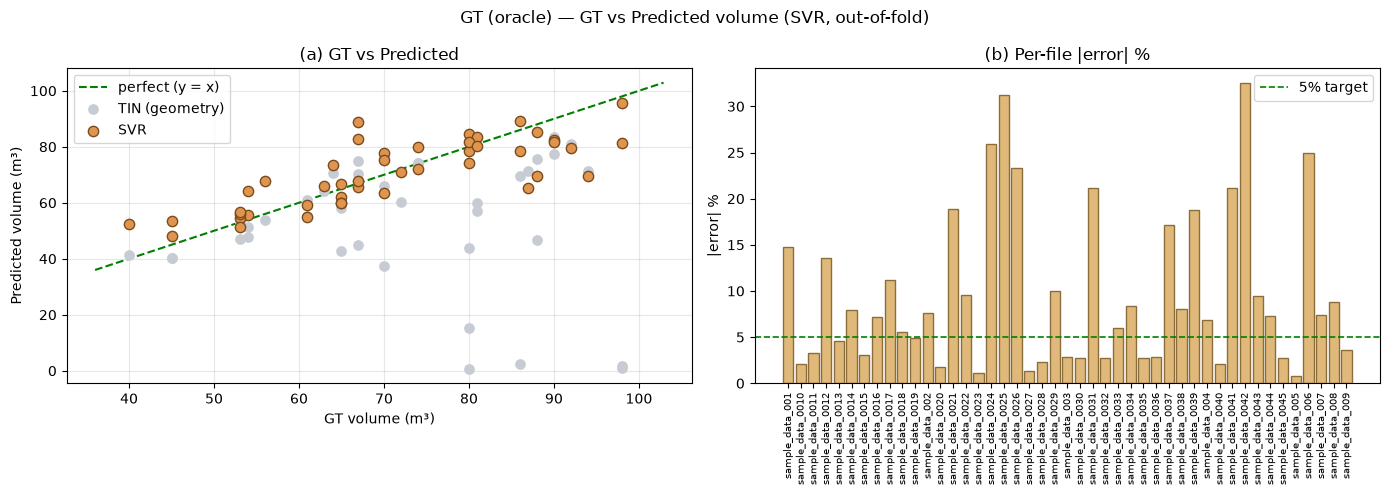

Saved → ../results/per_file_volume_gt.csv

=== PTv2 (e2e): per-file GT vs predicted (ExtraTrees, out-of-fold) ===
            file GT_volume_m3 pred_ExtraTrees TIN_geometry error_m3 error_pct
sample_data_0031         88.0            56.6         46.8    -31.4      35.7
sample_data_0025         40.0            54.2         43.1     14.2      35.6
sample_data_0011         54.0            69.3         52.0     15.3      28.4
sample_data_0024         94.0            73.8         68.7    -20.2      21.5
sample_data_0042         67.0            79.8         54.6     12.8      19.2
sample_data_0021         45.0            52.9         40.5      7.9      17.6
 sample_data_004         53.0            61.8         62.7      8.8      16.5
sample_data_0012         92.0            77.4         91.0    -14.6      15.9
 sample_data_009         86.0            73.0         73.3    -13.0      15.1
sample_data_0014         65.0            56.3         61.1     -8.7      13.4
sample_data_0015         88.

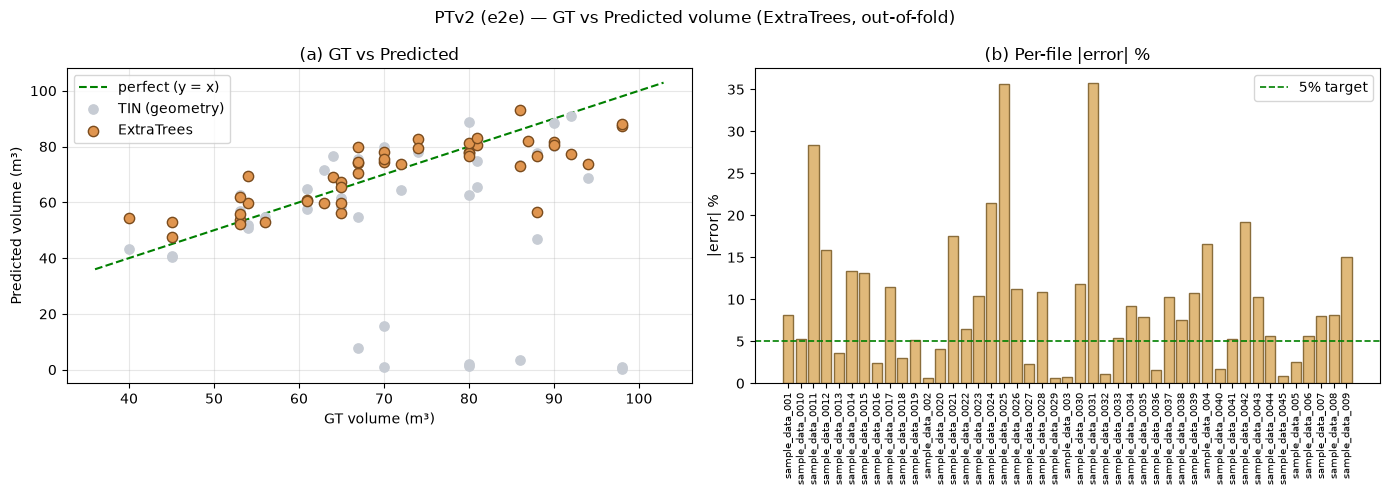

Saved → ../results/per_file_volume_ptv2.csv


In [25]:
from sklearn.model_selection import KFold

def per_file_prediction_table(X, y, names, tin, res_df, tag):
    """Out-of-fold per-file predictions with the best regressor from res_df."""
    best_name = res_df.iloc[0]["method"]
    if best_name.startswith("vol_TIN"):                     # geometry won? still show best learned too
        best_name = res_df.iloc[1]["method"]
    reg = make_regressors()[best_name]

    preds = np.zeros(len(y))
    kf = KFold(n_splits=VOL_CONFIG["cv_folds"], shuffle=True,
               random_state=VOL_CONFIG["random_state"])
    for tr, te in kf.split(X):
        from sklearn.base import clone
        preds[te] = clone(reg).fit(X[tr], y[tr]).predict(X[te])

    df = pd.DataFrame({
        "file"            : names,
        "GT_volume_m3"    : y,
        f"pred_{best_name}": preds,
        "TIN_geometry"    : tin,
    })
    df["error_m3"]  = df[f"pred_{best_name}"] - df["GT_volume_m3"]
    df["error_pct"] = 100 * df["error_m3"].abs() / df["GT_volume_m3"]
    df = df.sort_values("error_pct", ascending=False).reset_index(drop=True)

    print(f"\n=== {tag}: per-file GT vs predicted ({best_name}, out-of-fold) ===")
    print(df.to_string(index=False, formatters={
        c: "{:.1f}".format for c in df.columns if c != "file"}))
    print(f"\n{tag} summary: MAPE={df['error_pct'].mean():.2f}% | "
          f"median={df['error_pct'].median():.2f}% | "
          f"worst file: {df.iloc[0]['file']} ({df.iloc[0]['error_pct']:.1f}%)")

    # ── plots ──
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{tag} — GT vs Predicted volume ({best_name}, out-of-fold)")

    lo, hi = min(y.min(), preds.min())*0.9, max(y.max(), preds.max())*1.05
    ax[0].plot([lo, hi], [lo, hi], "g--", lw=1.5, label="perfect (y = x)")
    ax[0].scatter(y, tin,   s=45, c="#c7ccd4", label="TIN (geometry)", zorder=2)
    ax[0].scatter(y, preds, s=55, c="#e0954f", edgecolor="#7a4b1d",
                  label=best_name, zorder=3)
    ax[0].set_xlabel("GT volume (m³)"); ax[0].set_ylabel("Predicted volume (m³)")
    ax[0].set_title("(a) GT vs Predicted"); ax[0].legend(); ax[0].grid(alpha=0.3)

    order = np.argsort(names)
    ax[1].bar(np.array(names)[order], df.set_index("file")["error_pct"].reindex(
              np.array(names)[order]).values, color="#e0b97a", edgecolor="#8a6d3b")
    ax[1].axhline(5, color="green", ls="--", lw=1.2, label="5% target")
    ax[1].set_title("(b) Per-file |error| %"); ax[1].set_ylabel("|error| %")
    ax[1].tick_params(axis="x", rotation=90, labelsize=7); ax[1].legend()
    plt.tight_layout(); plt.show()

    out = f"../results/per_file_volume_{tag.split()[0].lower()}.csv"
    os.makedirs("../results", exist_ok=True)
    df.to_csv(out, index=False)
    print(f"Saved → {out}")
    return df

# দুই mode-এর per-file তুলনা
df_file_gt = per_file_prediction_table(X_gt, y_gt, names_gt, tin_gt, res_gt, "GT (oracle)")
df_file_pt = per_file_prediction_table(X_pt, y_pt, names_pt, tin_pt, res_pt, "PTv2 (e2e)")


In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def _heightmap_grid(powder, nrm, d, grid_res):
    """2D max-height grid above the floor plane (NaN = empty cell) + extent."""
    h = np.clip(powder@nrm + d, 0, None)
    x, y = powder[:,0], powder[:,1]
    nx = int(np.floor((x.max()-x.min())/grid_res))+1
    ny = int(np.floor((y.max()-y.min())/grid_res))+1
    ix = np.floor((x-x.min())/grid_res).astype(int)
    iy = np.floor((y-y.min())/grid_res).astype(int)
    grid = np.full((ny, nx), np.nan)
    np.fmax.at(grid, (iy, ix), h)   # fmax ignores the NaN init (maximum would keep NaN)
    return grid, (x.min(), x.max(), y.min(), y.max())

# ── Open3D: solid light-colour 3D view of the whole process ──────────────────
def visualize_volume_open3d(powder, env, nrm, d, title="Volume process"):
    """env=light blue-gray, powder=light yellow→brown by height, floor=light green slab."""
    import open3d as o3d
    geoms = []

    # environment — solid light blue-gray
    p_env = o3d.geometry.PointCloud()
    p_env.points = o3d.utility.Vector3dVector(env)
    p_env.paint_uniform_color([0.78, 0.82, 0.88])
    geoms.append(p_env)

    # powder — light gradient by height above floor (YlOrBr, light band only)
    h = np.clip(powder@nrm + d, 0, None)
    t = (h - h.min()) / max(h.max()-h.min(), 1e-9)
    cmap = mpl.colormaps["YlOrBr"]          # mpl>=3.9: cm.get_cmap is removed
    colors = cmap(0.15 + 0.55*t)[:, :3]     # stay in the light band
    p_pow = o3d.geometry.PointCloud()
    p_pow.points = o3d.utility.Vector3dVector(powder-np.mean(powder,axis=0))
    p_pow.colors = o3d.utility.Vector3dVector(colors)
    geoms.append(p_pow)

    # fitted floor plane — thin solid light-green slab under the powder footprint
    x0,x1 = powder[:,0].min()-0.3, powder[:,0].max()+0.3
    y0,y1 = powder[:,1].min()-0.3, powder[:,1].max()+0.3
    zc = -(nrm[0]*(x0+x1)/2 + nrm[1]*(y0+y1)/2 + d) / max(nrm[2], 1e-9)
    slab = o3d.geometry.TriangleMesh.create_box(x1-x0, y1-y0, 0.03)
    slab.translate([x0, y0, zc-0.03])
    slab.paint_uniform_color([0.70, 0.90, 0.70])
    slab.compute_vertex_normals()
    geoms.append(slab)

    span = float(np.ptp(powder, axis=0).max())*0.4
    geoms.append(o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=span, origin=powder.mean(0)))
    o3d.visualization.draw_geometries(geoms, window_name=title,
                                      width=1280, height=800)

# ── Matplotlib: 4-panel process explanation ──────────────────────────────────
def plot_volume_process(powder, env, nrm, d, grid_res=0.05,
                        gt=None, extra_vols=None, fname="", save_to=None):
    """(a) height-map, (b) side view + floor line, (c) height hist, (d) volume bars."""
    grid, ext = _heightmap_grid(powder, nrm, d, grid_res)
    hm_vol = np.nansum(grid)*grid_res*grid_res
    h = np.clip(powder@nrm + d, 0, None)

    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"Volume estimation process — {fname}", fontsize=13)

    im = ax[0,0].imshow(grid, origin="lower", extent=ext, cmap="YlOrBr", aspect="equal")
    ax[0,0].set_title(f"(a) Height-map above floor  →  Σ h·cell² = {hm_vol:.1f} m³")
    ax[0,0].set_xlabel("X (m)"); ax[0,0].set_ylabel("Y (m)")
    fig.colorbar(im, ax=ax[0,0], label="height (m)", shrink=0.8)

    sub_e = env[::max(len(env)//8000,1)]
    sub_p = powder[::max(len(powder)//8000,1)]
    ax[0,1].scatter(sub_e[:,0], sub_e[:,2], s=1, c="#c7ccd4", label="environment")
    sc = ax[0,1].scatter(sub_p[:,0], sub_p[:,2], s=1,
                         c=np.clip(sub_p@nrm+d,0,None), cmap="YlOrBr")
    xs = np.linspace(powder[:,0].min(), powder[:,0].max(), 50)
    ym = powder[:,1].mean()
    ax[0,1].plot(xs, -(nrm[0]*xs+nrm[1]*ym+d)/max(nrm[2],1e-9),
                 c="green", lw=2.5, label="fitted floor plane")
    ax[0,1].set_title("(b) Side view (X–Z): powder + floor reference")
    ax[0,1].set_xlabel("X (m)"); ax[0,1].set_ylabel("Z (m)"); ax[0,1].legend(markerscale=6)
    fig.colorbar(sc, ax=ax[0,1], label="h above floor (m)", shrink=0.8)

    ax[1,0].hist(h, bins=60, color="#e8c98a", edgecolor="#b08d4f")
    ax[1,0].set_title("(c) Powder height distribution above floor")
    ax[1,0].set_xlabel("height (m)"); ax[1,0].set_ylabel("points")

    bars = {"heightmap": hm_vol}
    if extra_vols: bars.update(extra_vols)
    if gt is not None: bars["GT"] = gt
    cols = ["#8fbc8f" if k=="GT" else "#e0b97a" for k in bars]
    ax[1,1].bar(list(bars.keys()), list(bars.values()), color=cols, edgecolor="#777")
    for i,(k,v) in enumerate(bars.items()):
        ax[1,1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ax[1,1].set_title("(d) Volume by method vs GT (m³)")
    ax[1,1].set_ylabel("m³")

    plt.tight_layout()
    if save_to: plt.savefig(save_to, dpi=110, bbox_inches="tight")
    plt.show()
    return hm_vol


### Demo — একটি GT file-এ পুরো প্রক্রিয়া দেখুন

sample_data_001: GT=64 m³ | floor tilt=1.2°


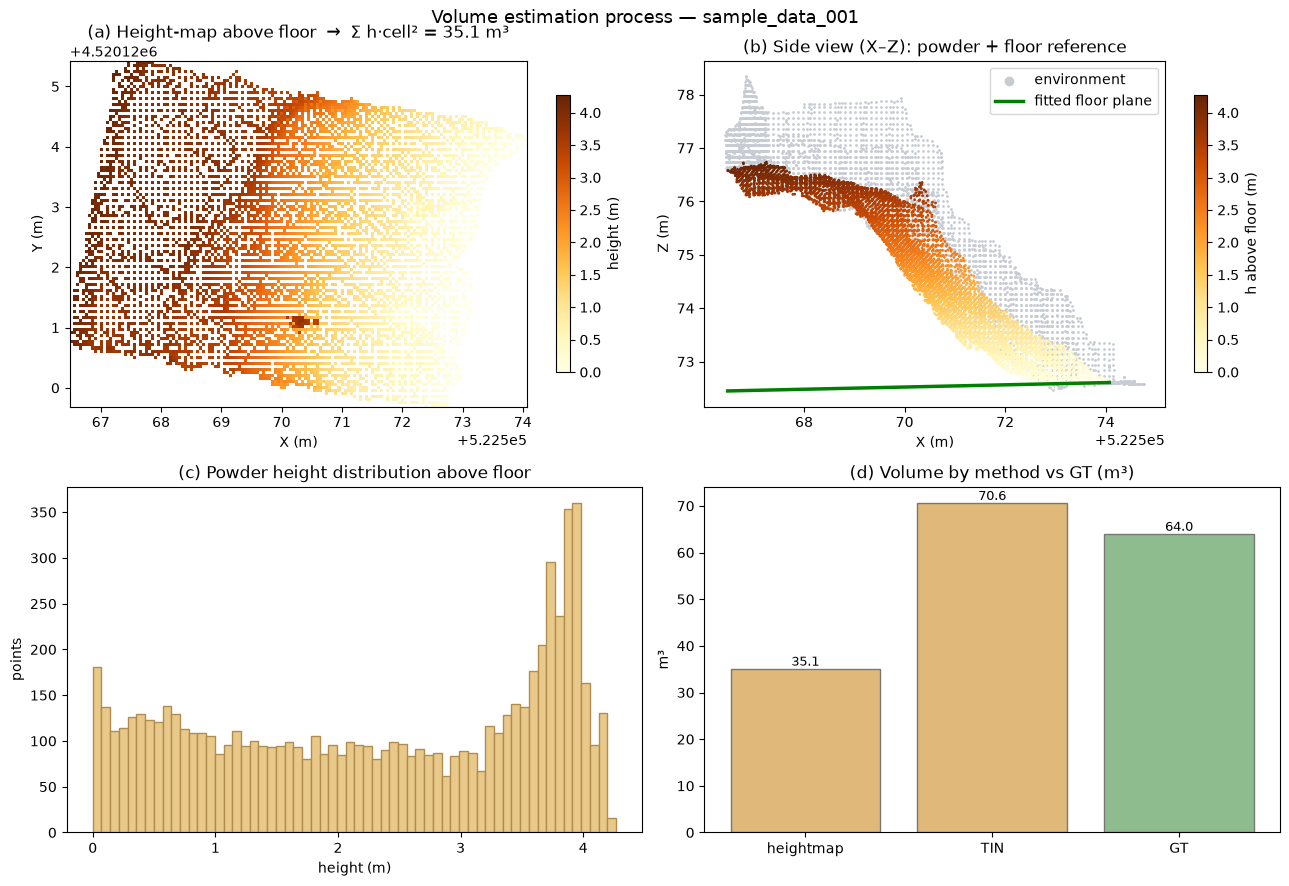

In [29]:
# প্রথম GT file নিয়ে demo (চাইলে stem বদলান)
demo_path = next(p for p in list_files(VOL_CONFIG["label_dir"])
                 if os.path.splitext(os.path.basename(p))[0] in gt_vol)
demo_stem = os.path.splitext(os.path.basename(demo_path))[0]

powder, env = powder_env_from_file(demo_path, use_gt_labels=True)
nrm, d = fit_floor_plane(env, VOL_CONFIG["floor_lo_pct"], VOL_CONFIG["ransac_thresh"])
tilt = np.degrees(np.arccos(np.clip(abs(nrm[2]), 0, 1)))
print(f"{demo_stem}: GT={gt_vol[demo_stem]:.0f} m³ | floor tilt={tilt:.1f}°")

v_tin, _ = vol_TIN(powder, floor_pct=2.0, run_bootstrap=False)

# Matplotlib — inline, প্রক্রিয়ার ৪টি ধাপ এক ছবিতে
plot_volume_process(powder, env, nrm, d, grid_res=VOL_CONFIG["grid_res"],
                    gt=gt_vol[demo_stem], extra_vols={"TIN": v_tin},
                    fname=demo_stem)

# Open3D — desktop window (server/headless হলে এই লাইনটি comment করুন)
visualize_volume_open3d(powder, env, nrm, d,
                        title=f"Volume process | {demo_stem} | GT={gt_vol[demo_stem]:.0f} m³")
